# **Import Library**

In [1]:
!pip install tld
!pip install googlesearch-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.8/263.8 kB 6.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import re

from tld import get_tld
from urllib.parse import urlparse
from googlesearch import search

# **Load Dataset**

In [8]:
#load file excel
data = pd.read_excel('/content/Malicious URLs From Manu.xlsx')

In [9]:
data.head()

,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://buzzfil.net/m/show-art/ils-etaient-loin...,benign
4,espn.go.com/nba/player/_/id/3457/brandon-rush,benign


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545796 entries, 0 to 545795
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   url     545796 non-null  object
 1   type    545796 non-null  object
dtypes: object(2)
memory usage: 8.3+ MB


# **Feature Extraction**

In [11]:
data.isnull().sum()

,0
url,0
type,0


In [12]:
data['type'].value_counts()

,count
type,
benign,428059
phishing,94092
malware,23645


In [13]:
#to create a mapping between the values ​​in the 'type' column
mapping = {'benign': 'good', 'defacement': 'bad', 'phishing': 'bad', 'malware': 'bad'}

In [14]:
#to replace the value in the 'type' column based on the value specified in the mapping variable
data['type'] = data['type'].replace(mapping)

In [15]:
#to count the number of occurrences of each unique value in the 'type' column after mapping.
data['type'].value_counts()

,count
type,
good,428059
bad,117737


In [16]:
#to display the first 5 rows of the dataframe after mapping
data.head()

,url,type
0,br-icloud.com.br,bad
1,mp3raid.com/music/krizz_kaliko.html,good
2,bopsecrets.org/rexroth/cr/1.htm,good
3,http://buzzfil.net/m/show-art/ils-etaient-loin...,good
4,espn.go.com/nba/player/_/id/3457/brandon-rush,good


In [17]:
#add a column to count the length (number of characters) of each URL
def url_length(url):
    return len(str(url))

data['url_length'] = data['url'].apply(lambda i: url_length(i))
data

,url,type,url_length
0,br-icloud.com.br,bad,16
1,mp3raid.com/music/krizz_kaliko.html,good,35
2,bopsecrets.org/rexroth/cr/1.htm,good,31
3,http://buzzfil.net/m/show-art/ils-etaient-loin...,good,118
4,espn.go.com/nba/player/_/id/3457/brandon-rush,good,45
...,...,...,...
545791,xbox360.ign.com/objects/850/850402.html,bad,39
545792,games.teamxbox.com/xbox-360/1860/Dead-Space/,bad,44
545793,www.gamespot.com/xbox360/action/deadspace/,bad,42
545794,en.wikipedia.org/wiki/Dead_Space_(video_game),bad,45


In [18]:
#add a column to calculate the length (number of characters) of the hostname
def hostname_length(url):
    return len(urlparse(url).netloc)

data['hostname_length'] = data['url'].apply(lambda i: hostname_length(i))
data

,url,type,url_length,hostname_length
0,br-icloud.com.br,bad,16,0
1,mp3raid.com/music/krizz_kaliko.html,good,35,0
2,bopsecrets.org/rexroth/cr/1.htm,good,31,0
3,http://buzzfil.net/m/show-art/ils-etaient-loin...,good,118,11
4,espn.go.com/nba/player/_/id/3457/brandon-rush,good,45,0
...,...,...,...,...
545791,xbox360.ign.com/objects/850/850402.html,bad,39,0
545792,games.teamxbox.com/xbox-360/1860/Dead-Space/,bad,44,0
545793,www.gamespot.com/xbox360/action/deadspace/,bad,42,0
545794,en.wikipedia.org/wiki/Dead_Space_(video_game),bad,45,0


In [19]:
#add a column to count the frequency of www occurrences
def count_www(url):
    url.count('www')
    return url.count('www')

data['count-www'] = data['url'].apply(lambda i: count_www(i))

In [20]:
#add a column to count the frequency of occurrence of https and http
def count_https(url):
    return url.count('https')

data['count-https'] = data['url'].apply(lambda i : count_https(i))

def count_http(url):
    return url.count('http')

data['count-http'] = data['url'].apply(lambda i : count_http(i))

In [21]:
#add a column to count the frequency of occurrence of unique characters (., %.+, ?, -, =, @, /, //)
def count_dot(url):
    count_dot = url.count('.')
    return count_dot

data['count.'] = data['url'].apply(lambda i: count_dot(i))

def count_per(url):
    return url.count('%')

data['count%'] = data['url'].apply(lambda i : count_per(i))

def count_ques(url):
    return url.count('?')

data['count?'] = data['url'].apply(lambda i: count_ques(i))

def count_hyphen(url):
    return url.count('-')

data['count-'] = data['url'].apply(lambda i: count_hyphen(i))

def count_equal(url):
    return url.count('=')

data['count='] = data['url'].apply(lambda i: count_equal(i))

def count_atrate(url):

    return url.count('@')

data['count@'] = data['url'].apply(lambda i: count_atrate(i))

def no_of_dir(url):
    urldir = urlparse(url).path
    return urldir.count('/')

data['count_dir'] = data['url'].apply(lambda i: no_of_dir(i))

def no_of_embed(url):
    urldir = urlparse(url).path
    return urldir.count('//')

data['count_embed_domian'] = data['url'].apply(lambda i: no_of_embed(i))

In [22]:
#to identify shortened URLs
def shortening_service(url):
    match = re.search('bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs|'
                      'yfrog\.com|migre\.me|ff\.im|tiny\.cc|url4\.eu|twit\.ac|su\.pr|twurl\.nl|snipurl\.com|'
                      'short\.to|BudURL\.com|ping\.fm|post\.ly|Just\.as|bkite\.com|snipr\.com|fic\.kr|loopt\.us|'
                      'doiop\.com|short\.ie|kl\.am|wp\.me|rubyurl\.com|om\.ly|to\.ly|bit\.do|t\.co|lnkd\.in|'
                      'db\.tt|qr\.ae|adataset\.ly|goo\.gl|bitly\.com|cur\.lv|tinyurl\.com|ow\.ly|bit\.ly|ity\.im|'
                      'q\.gs|is\.gd|po\.st|bc\.vc|twitthis\.com|u\.to|j\.mp|buzurl\.com|cutt\.us|u\.bb|yourls\.org|'
                      'x\.co|prettylinkpro\.com|scrnch\.me|filoops\.info|vzturl\.com|qr\.net|1url\.com|tweez\.me|v\.gd|'
                      'tr\.im|link\.zip\.net',
                      url)
    if match:
        return 1
    else:
        return 0

data['short_url'] = data['url'].apply(lambda i: shortening_service(i))

In [23]:
#to calculate the length of the first directory by dividing the URL path into parts using the '/' character
def fd_length(url):
    urlpath= urlparse(url).path
    try:
        return len(urlpath.split('/')[1])
    except:
        return 0

data['fd_length'] = data['url'].apply(lambda i: fd_length(i))

#Length of Top Level Domain
data['tld'] = data['url'].apply(lambda i: get_tld(i,fail_silently=True))

def tld_length(tld):
    try:
        return len(tld)
    except:
        return -1

data['tld_length'] = data['tld'].apply(lambda i: tld_length(i))
data

,url,type,url_length,hostname_length,count-www,count-https,count-http,count.,count%,count?,count-,count=,count@,count_dir,count_embed_domian,short_url,fd_length,tld,tld_length
0,br-icloud.com.br,bad,16,0,0,0,0,2,0,0,1,0,0,0,0,0,0,None,-1
1,mp3raid.com/music/krizz_kaliko.html,good,35,0,0,0,0,2,0,0,0,0,0,2,0,0,5,None,-1
2,bopsecrets.org/rexroth/cr/1.htm,good,31,0,0,0,0,2,0,0,0,0,0,3,0,0,7,None,-1
3,http://buzzfil.net/m/show-art/ils-etaient-loin...,good,118,11,0,0,1,2,0,0,16,0,0,3,0,0,1,net,3
4,espn.go.com/nba/player/_/id/3457/brandon-rush,good,45,0,0,0,0,2,0,0,1,0,0,6,0,0,3,None,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545791,xbox360.ign.com/objects/850/850402.html,bad,39,0,0,0,0,3,0,0,0,0,0,3,0,0,7,None,-1
545792,games.teamxbox.com/xbox-360/1860/Dead-Space/,bad,44,0,0,0,0,2,0,0,2,0,0,4,0,1,8,None,-1
545793,www.gamespot.com/xbox360/action/deadspace/,bad,42,0,1,0,0,2,0,0,0,0,0,4,0,1,7,None,-1
545794,en.wikipedia.org/wiki/Dead_Space_(video_game),bad,45,0,0,0,0,2,0,0,0,0,0,2,0,0,4,None,-1


In [24]:
#to check whether the URL contains suspicious words related to online fraud links.
def suspicious_words(url):
    match = re.search('PayPal|login|signin|bank|account|update|free|lucky|service|bonus|ebayisapi|webscr',
                      url)
    if match:
        return 1
    else:
        return 0

data['sus_url'] = data['url'].apply(lambda i: suspicious_words(i))


def digit_count(url):
    digits = 0
    for i in url:
        if i.isnumeric():
            digits = digits + 1
    return digits

data['count-digits']= data['url'].apply(lambda i: digit_count(i))


def letter_count(url):
    letters = 0
    for i in url:
        if i.isalpha():
            letters = letters + 1
    return letters


data['count-letters']= data['url'].apply(lambda i: letter_count(i))
data

,url,type,url_length,hostname_length,count-www,count-https,count-http,count.,count%,count?,...,count@,count_dir,count_embed_domian,short_url,fd_length,tld,tld_length,sus_url,count-digits,count-letters
0,br-icloud.com.br,bad,16,0,0,0,0,2,0,0,...,0,0,0,0,0,None,-1,0,0,13
1,mp3raid.com/music/krizz_kaliko.html,good,35,0,0,0,0,2,0,0,...,0,2,0,0,5,None,-1,0,1,29
2,bopsecrets.org/rexroth/cr/1.htm,good,31,0,0,0,0,2,0,0,...,0,3,0,0,7,None,-1,0,1,25
3,http://buzzfil.net/m/show-art/ils-etaient-loin...,good,118,11,0,0,1,2,0,0,...,0,3,0,0,1,net,3,0,1,93
4,espn.go.com/nba/player/_/id/3457/brandon-rush,good,45,0,0,0,0,2,0,0,...,0,6,0,0,3,None,-1,0,4,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545791,xbox360.ign.com/objects/850/850402.html,bad,39,0,0,0,0,3,0,0,...,0,3,0,0,7,None,-1,0,12,21
545792,games.teamxbox.com/xbox-360/1860/Dead-Space/,bad,44,0,0,0,0,2,0,0,...,0,4,0,1,8,None,-1,0,7,29
545793,www.gamespot.com/xbox360/action/deadspace/,bad,42,0,1,0,0,2,0,0,...,0,4,0,1,7,None,-1,0,3,33
545794,en.wikipedia.org/wiki/Dead_Space_(video_game),bad,45,0,0,0,0,2,0,0,...,0,2,0,0,4,None,-1,0,0,36


In [25]:
#to detect suspicious URLs
def abnormal_url(url):
    hostname = urlparse(url).hostname
    hostname = str(hostname)
    match = re.search(hostname, url)
    if match:
        # print match.group()
        return 1
    else:
        # print 'No matching pattern found'
        return 0
data['abnormal_url'] = data['url'].apply(lambda i: abnormal_url(i))
data

,url,type,url_length,hostname_length,count-www,count-https,count-http,count.,count%,count?,...,count_dir,count_embed_domian,short_url,fd_length,tld,tld_length,sus_url,count-digits,count-letters,abnormal_url
0,br-icloud.com.br,bad,16,0,0,0,0,2,0,0,...,0,0,0,0,None,-1,0,0,13,0
1,mp3raid.com/music/krizz_kaliko.html,good,35,0,0,0,0,2,0,0,...,2,0,0,5,None,-1,0,1,29,0
2,bopsecrets.org/rexroth/cr/1.htm,good,31,0,0,0,0,2,0,0,...,3,0,0,7,None,-1,0,1,25,0
3,http://buzzfil.net/m/show-art/ils-etaient-loin...,good,118,11,0,0,1,2,0,0,...,3,0,0,1,net,3,0,1,93,1
4,espn.go.com/nba/player/_/id/3457/brandon-rush,good,45,0,0,0,0,2,0,0,...,6,0,0,3,None,-1,0,4,31,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545791,xbox360.ign.com/objects/850/850402.html,bad,39,0,0,0,0,3,0,0,...,3,0,0,7,None,-1,0,12,21,0
545792,games.teamxbox.com/xbox-360/1860/Dead-Space/,bad,44,0,0,0,0,2,0,0,...,4,0,1,8,None,-1,0,7,29,0
545793,www.gamespot.com/xbox360/action/deadspace/,bad,42,0,1,0,0,2,0,0,...,4,0,1,7,None,-1,0,3,33,0
545794,en.wikipedia.org/wiki/Dead_Space_(video_game),bad,45,0,0,0,0,2,0,0,...,2,0,0,4,None,-1,0,0,36,0


In [26]:
#to check if a URL contains an IP address
def having_ip_address(url: str) -> int:
    match = re.search(
        '(([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.'
        '([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\/)|'  # IPv4
        '((0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\/)' # IPv4 in hexadecimal
        '(?:[a-fA-F0-9]{1,4}:){7}[a-fA-F0-9]{1,4}', url)  # Ipv6
    if match:
        # print match.group()
        return 1
    else:
        # print 'No matching pattern found'
        return 0
data['use_of_ip_address'] = data['url'].apply(lambda i: having_ip_address(i))
data

,url,type,url_length,hostname_length,count-www,count-https,count-http,count.,count%,count?,...,count_embed_domian,short_url,fd_length,tld,tld_length,sus_url,count-digits,count-letters,abnormal_url,use_of_ip_address
0,br-icloud.com.br,bad,16,0,0,0,0,2,0,0,...,0,0,0,None,-1,0,0,13,0,0
1,mp3raid.com/music/krizz_kaliko.html,good,35,0,0,0,0,2,0,0,...,0,0,5,None,-1,0,1,29,0,0
2,bopsecrets.org/rexroth/cr/1.htm,good,31,0,0,0,0,2,0,0,...,0,0,7,None,-1,0,1,25,0,0
3,http://buzzfil.net/m/show-art/ils-etaient-loin...,good,118,11,0,0,1,2,0,0,...,0,0,1,net,3,0,1,93,1,0
4,espn.go.com/nba/player/_/id/3457/brandon-rush,good,45,0,0,0,0,2,0,0,...,0,0,3,None,-1,0,4,31,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545791,xbox360.ign.com/objects/850/850402.html,bad,39,0,0,0,0,3,0,0,...,0,0,7,None,-1,0,12,21,0,0
545792,games.teamxbox.com/xbox-360/1860/Dead-Space/,bad,44,0,0,0,0,2,0,0,...,0,1,8,None,-1,0,7,29,0,0
545793,www.gamespot.com/xbox360/action/deadspace/,bad,42,0,1,0,0,2,0,0,...,0,1,7,None,-1,0,3,33,0,0
545794,en.wikipedia.org/wiki/Dead_Space_(video_game),bad,45,0,0,0,0,2,0,0,...,0,0,4,None,-1,0,0,36,0,0


In [27]:
#to count the number of occurrences of each unique value in the 'use_of_ip_address' column
data['use_of_ip_address'].value_counts()

,count
use_of_ip_address,
0,538504
1,7292


In [28]:
#to search for a URL in Google search results
def google_index(url):
    site = search(url, 5)
    return 1 if site else 0
data['google_index'] = data['url'].apply(lambda i: google_index(i))
data

,url,type,url_length,hostname_length,count-www,count-https,count-http,count.,count%,count?,...,short_url,fd_length,tld,tld_length,sus_url,count-digits,count-letters,abnormal_url,use_of_ip_address,google_index
0,br-icloud.com.br,bad,16,0,0,0,0,2,0,0,...,0,0,None,-1,0,0,13,0,0,1
1,mp3raid.com/music/krizz_kaliko.html,good,35,0,0,0,0,2,0,0,...,0,5,None,-1,0,1,29,0,0,1
2,bopsecrets.org/rexroth/cr/1.htm,good,31,0,0,0,0,2,0,0,...,0,7,None,-1,0,1,25,0,0,1
3,http://buzzfil.net/m/show-art/ils-etaient-loin...,good,118,11,0,0,1,2,0,0,...,0,1,net,3,0,1,93,1,0,1
4,espn.go.com/nba/player/_/id/3457/brandon-rush,good,45,0,0,0,0,2,0,0,...,0,3,None,-1,0,4,31,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545791,xbox360.ign.com/objects/850/850402.html,bad,39,0,0,0,0,3,0,0,...,0,7,None,-1,0,12,21,0,0,1
545792,games.teamxbox.com/xbox-360/1860/Dead-Space/,bad,44,0,0,0,0,2,0,0,...,1,8,None,-1,0,7,29,0,0,1
545793,www.gamespot.com/xbox360/action/deadspace/,bad,42,0,1,0,0,2,0,0,...,1,7,None,-1,0,3,33,0,0,1
545794,en.wikipedia.org/wiki/Dead_Space_(video_game),bad,45,0,0,0,0,2,0,0,...,0,4,None,-1,0,0,36,0,0,1


In [29]:
data.isnull().sum()

,0
url,0
type,0
url_length,0
hostname_length,0
count-www,0
count-https,0
count-http,0
count.,0
count%,0
count?,0


In [30]:
data.dropna(inplace=True)

In [31]:
#to check whether the missing value has been deleted
data.isnull().sum()

,0
url,0
type,0
url_length,0
hostname_length,0
count-www,0
count-https,0
count-http,0
count.,0
count%,0
count?,0


In [32]:
#identify the number of samples for each class
class_counts = data['type'].value_counts()

#take the lowest number of samples among the classes
min_samples = class_counts.min()

#calculate the maximum number of samples of class "bad" and make it the maximum sample
max_samples = class_counts['bad']

#oversampling  for class "bad"
bad_data = data[data['type'] == 'bad']
oversampled_bad_data = resample(bad_data, replace=True, n_samples=max_samples, random_state=42)

#undersampling for class "good"
good_data = data[data['type'] == 'good']
undersampled_good_data = good_data.sample(n=max_samples, replace=True, random_state=42)

#merge data
balanced_data = pd.concat([oversampled_bad_data, undersampled_good_data])

#display the balanced data
balanced_data['type'].value_counts()

,count
type,
bad,35182
good,35182


In [33]:
#encoding
lb_make = LabelEncoder()
balanced_data['class_type'] = lb_make.fit_transform(balanced_data['type'])
balanced_data['class_type'].value_counts()

,count
class_type,
0,35182
1,35182


# **Spliting Data**

In [34]:
#create 2 variables to train the model and set the target
X_balanced = balanced_data[['use_of_ip_address','abnormal_url', 'google_index', 'count-www', 'count@',
           'count_dir', 'count_embed_domian', 'short_url', 'count-https',
           'count-http', 'count%', 'count?', 'count-', 'count=', 'url_length',
           'hostname_length', 'sus_url', 'fd_length', 'tld_length', 'count-digits',
           'count-letters']]
y_balanced = balanced_data['class_type']

In [35]:
#split data
x_train , x_test , Y_train , Y_test = train_test_split(X_balanced, y_balanced, test_size = 0.2)

# **Model Training and Testing Logistic Regression**

In [36]:
#applying the Logistic Regression model
from sklearn.linear_model import LogisticRegression

classifier3 = LogisticRegression(max_iter=2000, random_state=42)
classifier3.fit(x_train, Y_train)
y_pred3 = classifier3.predict(x_test)

In [38]:
#calculate accuracy on training and test data
train_acc3 = classifier3.score(x_train, Y_train)
test_acc3 = accuracy_score(Y_test, y_pred3)

#show accuracy
print("Accuracy for data training:", train_acc3)
print("Accuracy for data test:", test_acc3)

Accuracy for data training: 0.9309836385923149
Accuracy for data test: 0.9290130036239608


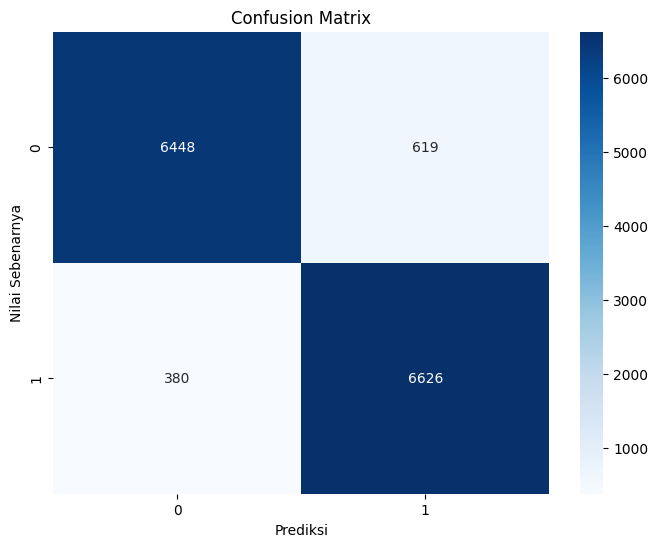

In [39]:
# Confusion matrix
cm3 = confusion_matrix(Y_test, y_pred3)

#make a plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm3, annot=True, cmap='Blues', fmt='g')

#add labels and titles
plt.xlabel('Prediksi')
plt.ylabel('Nilai Sebenarnya')
plt.title('Confusion Matrix')
plt.show()

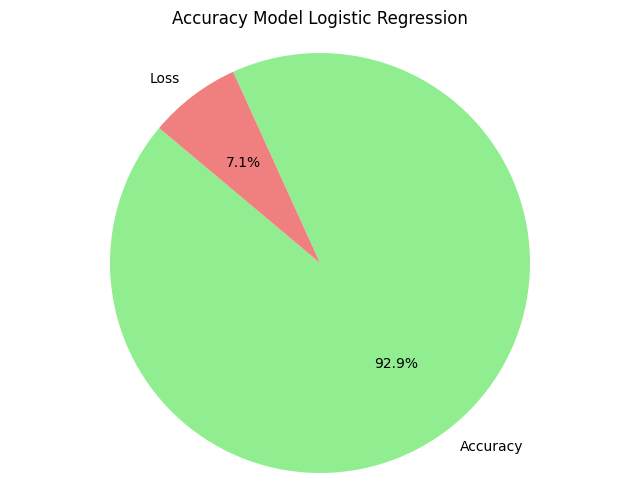

In [41]:
#accuracy value
accuracy3 = accuracy_score(Y_test, y_pred3)

#accuracy and error percentage
accuracies = [accuracy3, 1-accuracy3]
labels = ['Accuracy', 'Loss']
colors = ['lightgreen', 'lightcoral']

#plot pie chart
plt.figure(figsize=(8, 6))
plt.pie(accuracies, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Accuracy Model Logistic Regression')
plt.axis('equal')
plt.show()

In [42]:
print(classification_report(Y_test, y_pred3))

              precision    recall  f1-score   support

           0       0.94      0.91      0.93      7067
           1       0.91      0.95      0.93      7006

    accuracy                           0.93     14073
   macro avg       0.93      0.93      0.93     14073
weighted avg       0.93      0.93      0.93     14073



In [43]:
#define model
model = LogisticRegression(max_iter=2000)

#perform cross-validation with 5-fold
scores = cross_val_score(model, X_balanced, y_balanced, cv=5)

#calculate average accuracy and standard deviation
mean_accuracy = np.mean(scores)
std_deviation = np.std(scores)

print("Rata-rata Accuracy:", mean_accuracy)
print("Standar deviation Accuracy:", std_deviation)

Rata-rata Accuracy: 0.930660619339417
Standar deviation Accuracy: 0.0021575812522773466


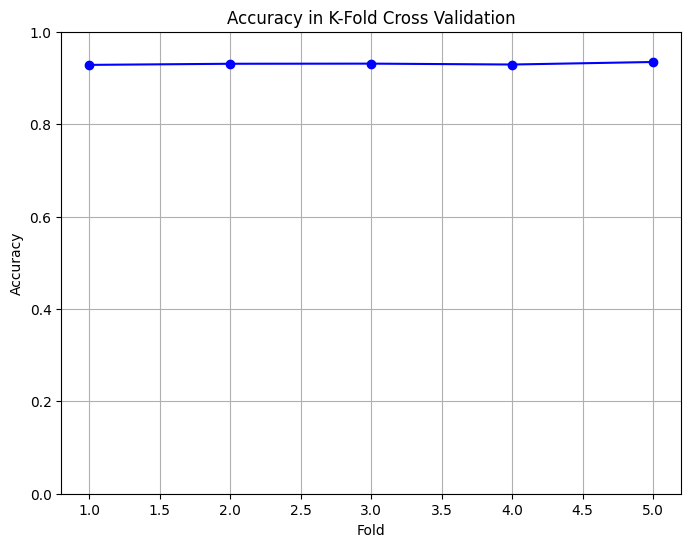

In [44]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, 6), scores, marker='o', color='blue', linestyle='-')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy in K-Fold Cross Validation')
plt.ylim(0, 1)
plt.grid(True)
plt.show()

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [46]:
import joblib

# save model
joblib.dump(classifier3, '/content/drive/MyDrive/logistic_regression_model.pkl')

['/content/drive/MyDrive/logistic_regression_model.pkl']

In [47]:
# save model
loaded_model = joblib.load('/content/drive/MyDrive/logistic_regression_model.pkl')

In [51]:
def extract_features(url):
    features = {}


    features['url_length'] = len(url)


    features['hostname_length'] = len(urlparse(url).netloc)


    features['count-www'] = url.count('www')


    features['count-https'] = url.count('https')
    features['count-http'] = url.count('http')


    features['count.'] = url.count('.')


    features['count%'] = url.count('%')


    features['count?'] = url.count('?')


    features['count-'] = url.count('-')


    features['count='] = url.count('=')


    features['count@'] = url.count('@')


    features['count_dir'] = urlparse(url).path.count('/')


    features['count_embed_domian'] = urlparse(url).path.count('//')


    features['short_url'] = shortening_service(url)


    features['fd_length'] = len(urlparse(url).path.split('/')[1]) if len(urlparse(url).path.split('/')) > 1 else 0


    tld = get_tld(url, fail_silently=True)
    features['tld_length'] = len(tld) if tld else -1


    features['sus_url'] = suspicious_words(url)


    features['count-digits'] = sum(c.isdigit() for c in url)


    features['count-letters'] = sum(c.isalpha() for c in url)


    features['abnormal_url'] = abnormal_url(url)


    features['use_of_ip_address'] = having_ip_address(url)


    features['google_index'] = google_index(url)

    return features

def predict_url(url):
    # Extract features from link
    features = extract_features(url)

    # Convert features to a DataFrame with specified column names
    features_df = pd.DataFrame([features], columns=[
        'use_of_ip_address', 'abnormal_url', 'google_index', 'count-www', 'count@',
        'count_dir', 'count_embed_domian', 'short_url', 'count-https',
        'count-http', 'count%', 'count?', 'count-', 'count=', 'url_length',
        'hostname_length', 'sus_url', 'fd_length', 'tld_length', 'count-digits',
        'count-letters'
    ])

    #Prediction using the model
    prediction = loaded_model.predict(features_df)

    # Convert the result to text
    result = 'bad' if prediction[0] == 1 else 'good'

    return result

In [54]:
# Test the form on a new link
new_url = "https://translate.google.com/?sl=auto&tl=en&text=Akurasi%20dalam%20Validasi%20Silang%20K-Fold&op=translate"
prediction = predict_url(new_url)
print(f"The URL is predicted to be: {prediction}")

The URL is predicted to be: good


In [55]:
# Test the form on a new link
new_url = "br-icloud.com.br"
prediction = predict_url(new_url)
print(f"The URL is predicted to be: {prediction}")

The URL is predicted to be: bad
